# ROS04 - Drive to a Coloured Block  (LeKiwi - ROS2 - Demo 2)

### Lab Description

ROS03 needed a human to click each goal; here the goal is **computed**. You name a colour (red/green/blue/purple) and the robot drives to that block and stops facing it - chain colours for a route. It reuses the ROS03 localization + Nav2 stack; the only new piece is `send_block_goal.py`, which turns a stored block position into a reachable, block-facing Nav2 goal. Below we define and run that logic on **your** map + block waypoints.

#### Recommended Hardware
**LeKiwi** omni-directional base (3x Feetech STS3215 wheels on `/dev/ttyACM0`) + **ZED 2i** stereo camera (USB UVC), driven from an **AMD Ryzen AI** machine (Radeon **gfx1152**, RDNA3.5) - AMD-only, no NVIDIA/CUDA.

#### Software Environment
OS: Ubuntu 24.04 - ROCm 7.13 - PyTorch 2.11 (gfx1152 wheel) - **ROS2 Jazzy** + Nav2 + RTAB-Map - conda env `lerobot-new`. This repo ships **only the LeKiwi ROS2 code** in `lekiwi_ros2/` (repo-relative, so it runs from a clone); it does **not** ship any pre-built map or example run - you produce those yourself on the robot. The `numpy`, `opencv-python`, `pyyaml`, `matplotlib` in `lerobot-new` are enough for the analysis cells. One-time robot setup (the `lerobot-new` env, `bash lekiwi_ros2/utils/setup_raft.sh`, `bash lekiwi_ros2/utils/get_calibration.sh <ZED serial>`) is in `lekiwi_ros2/README.md`.

## Goals
- Reuse the ROS03 navigation stack and add automatic, named goals
- Define and run `snap_to_free` and `block_to_goal` on YOUR map + block waypoints
- See each colour turned into a reachable, block-facing pose (Nav2 /navigate_to_pose goal)

> **How this notebook works.** Following the MT06 pattern, each key step is a runnable code cell that **defines the function** doing the work and then runs it. The scene-specific cells read **your own** data - the map *you* build (`utils/scene_map.*`), *your* recorded session (`demo0/rec/...`), *your* `odom.txt` - so **every student's result is different**. Before you have produced that data those cells print a short 'run the robot step first' hint (no canned example is shown). The steps that need the physical robot (camera, motors, ROS2) are `bash` commands you run on the LeKiwi; the full implementations live in `lekiwi_ros2/`.

In [6]:
import os, math, glob, configparser
import numpy as np, cv2, yaml
import matplotlib.pyplot as plt

# This repo ships only the LeKiwi ROS2 code (no pre-built map). You produce the map + data.
ROS2  = os.path.abspath("lekiwi_ros2")
UTILS = f"{ROS2}/utils"
print("repo ROS2 folder:", ROS2)

FREE, OCC, UNKNOWN = 254, 0, 205        # ROS map_server PGM pixel values (white / black / grey)
BLOCK_RGB = {"red": "#e53935", "green": "#43a047", "blue": "#1e88e5", "purple": "#8e24aa"}

def latest_session():
    """Newest recording YOU produced (demo0 manual or demo0-v2 auto). None until you record."""
    recs = sorted(glob.glob(f"{ROS2}/demo0/rec/map*") + glob.glob(f"{ROS2}/demo0-v2/rec/map*"))
    return recs[-1] if recs else None

def have_map(name="scene_map"):
    return os.path.exists(f"{UTILS}/{name}.pgm") and os.path.exists(f"{UTILS}/{name}.yaml")

def load_map(name="scene_map"):
    """Load the occupancy grid YOU built (build_map.sh writes it into utils/). Returns
    (grid, res, ox, oy) with grid[gy, gx], gy increasing upward (the ROS map frame)."""
    m = yaml.safe_load(open(f"{UTILS}/{name}.yaml"))
    res, (ox, oy, _) = m["resolution"], m["origin"]
    with open(f"{UTILS}/{m['image']}", "rb") as f:
        assert f.readline().split()[0] == b"P5"
        t = []
        while len(t) < 3:
            t += f.readline().split(b"#")[0].split()
        W, H = int(t[0]), int(t[1])
        raw = np.frombuffer(f.read(W * H), np.uint8).reshape(H, W)
    return np.ascontiguousarray(np.flipud(raw)), res, ox, oy

def new_map_ax(grid, res, ox, oy, title="", figsize=(6, 5)):
    """Show a grid in metric map-frame coordinates and return the Axes for metric overlays."""
    H, W = grid.shape
    ax = plt.subplots(figsize=figsize)[1]
    ax.imshow(grid, cmap="gray", vmin=0, vmax=255, origin="lower",
              extent=[ox, ox + W * res, oy, oy + H * res])
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")
    return ax

def load_waypoints():
    """The colour-block positions YOUR build_map.sh saved: {colour: (x, y)} in the map frame."""
    d = {}
    for ln in open(f"{UTILS}/block_waypoints.txt"):
        c, x, y = ln.split(); d[c] = (float(x), float(y))
    return d

def show_my_map():
    """Show the map YOU built, with your block waypoints. Hints if you have not built one yet."""
    if not have_map():
        print("No map yet. Build YOUR map first (run ROS01 or ROS02 on the robot), then re-run.")
        return
    grid, res, ox, oy = load_map()
    ax = new_map_ax(grid, res, ox, oy, "YOUR scene_map")
    if os.path.exists(f"{UTILS}/block_waypoints.txt"):
        for c, (x, y) in load_waypoints().items():
            ax.scatter(x, y, c=BLOCK_RGB.get(c, "orange"), s=90, ec="k", zorder=5, label=c)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

repo ROS2 folder: /home/aup/aup-teaching-labs/projects/Physical-AI/Real-Deployment/ROS2-Deployment/lekiwi_ros2


## Prerequisite - blocks in your map

Your `build_map.sh` (ROS01/ROS02) saved each block's position to `utils/block_waypoints.txt` and marked them on your map. Confirm they are there:

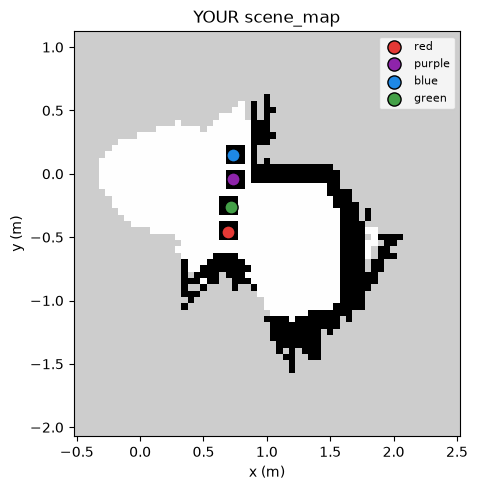

In [7]:
show_my_map()

## Run it on the robot

Name one or more colours; the robot visits them in order and stops facing each block. `Ctrl-C` stops and auto-cleans.

```bash
bash lekiwi_ros2/demo2/demo2_color_nav.sh blue                # go to the blue block
bash lekiwi_ros2/demo2/demo2_color_nav.sh green red           # green, then red (a route)
bash lekiwi_ros2/demo2/demo2_color_nav.sh red --standoff 0.05 # stop 5 cm back (default 0.10 m)
```

The bring-up is identical to ROS03; the one new line is `send_block_goal.py <colours>`, which we build up next.

## Step 1 - snap the block to a reachable cell

A block can sit against a wall, so you can't drive onto its exact coordinates. `snap_to_free` searches outward from the block for the nearest **free** cell (value 254) with enough clearance that the robot fits - faithful to `send_block_goal.py`. The run cell uses **your** map + waypoints:

In [8]:
def snap_to_free(bx, by, grid, res, ox, oy, clear_cells=3):
    """Nearest FREE cell to (bx, by) with `clear_cells` of clearance (the robot fits), so a
    block touching a wall is still reachable. Returns a grid cell (gx, gy)."""
    H, W = grid.shape
    gx0, gy0 = int((bx - ox) / res), int((by - oy) / res)
    def clear(gx, gy):
        if not (clear_cells <= gx < W-clear_cells and clear_cells <= gy < H-clear_cells):
            return False
        win = grid[gy-clear_cells:gy+clear_cells+1, gx-clear_cells:gx+clear_cells+1]
        return grid[gy, gx] == FREE and (win != OCC).all()
    if clear(gx0, gy0):
        return gx0, gy0
    for r in range(1, max(H, W)):        # expanding ring search
        best, bestd = None, 1e9
        for dx in range(-r, r+1):
            for dy in range(-r, r+1):
                if max(abs(dx), abs(dy)) != r:
                    continue
                gx, gy = gx0+dx, gy0+dy
                if clear(gx, gy) and dx*dx+dy*dy < bestd:
                    bestd, best = dx*dx+dy*dy, (gx, gy)
        if best:
            return best
    return gx0, gy0

if have_map() and os.path.exists(f"{UTILS}/block_waypoints.txt"):
    grid, res, ox, oy = load_map()
    for colour, (bx, by) in load_waypoints().items():
        gx, gy = snap_to_free(bx, by, grid, res, ox, oy)
        print(f"{colour:7s} block ({bx:+.2f}, {by:+.2f}) -> free cell ({gx}, {gy})")
else:
    print("No map + blocks yet. Build YOUR map (ROS01/ROS02) first, then re-run.")

red     block (+0.70, -0.46) -> free cell (19, 32)
purple  block (+0.73, -0.04) -> free cell (20, 41)
blue    block (+0.73, +0.15) -> free cell (20, 44)
green   block (+0.72, -0.26) -> free cell (19, 36)


## Step 2 - stand off and face the block

From that free cell, back off by `standoff` metres so the robot stops *in front* of the block, and set the goal heading to point *at* it. That pose is what goes to Nav2's `/navigate_to_pose` action. Run it for every block on **your** map and draw the goal + facing arrow:

red     -> goal (+0.35, -0.44) facing -3 deg
purple  -> goal (+0.40, +0.02) facing -11 deg
blue    -> goal (+0.40, +0.15) facing -1 deg
green   -> goal (+0.35, -0.24) facing -2 deg


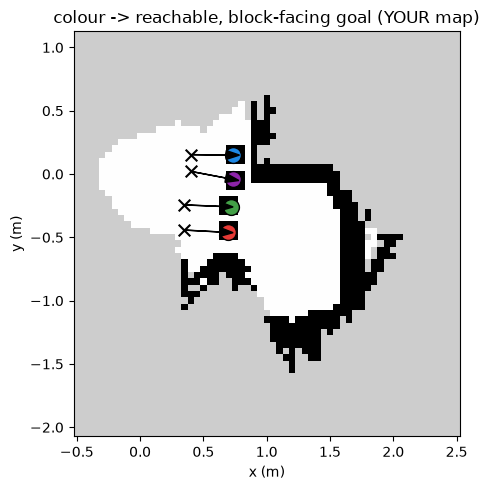

In [9]:
def block_to_goal(colour, grid, res, ox, oy, standoff=0.10):
    """Colour -> Nav2 goal (x, y, yaw): snap to a reachable free cell, stand off so we stop
    IN FRONT of the block, and face it. This is what send_block_goal.py sends to Nav2."""
    bx, by = load_waypoints()[colour]
    gx, gy = snap_to_free(bx, by, grid, res, ox, oy)
    x, y = ox + (gx+0.5)*res, oy + (gy+0.5)*res
    d = math.hypot(x - bx, y - by)
    if d > 1e-3:
        x += standoff * (x - bx) / d; y += standoff * (y - by) / d   # back off from the block
    yaw = math.atan2(by - y, bx - x)                                  # face the block
    return x, y, yaw

if have_map() and os.path.exists(f"{UTILS}/block_waypoints.txt"):
    grid, res, ox, oy = load_map()
    ax = new_map_ax(grid, res, ox, oy, "colour -> reachable, block-facing goal (YOUR map)")
    for colour, (bx, by) in load_waypoints().items():
        x, y, yaw = block_to_goal(colour, grid, res, ox, oy)
        ax.scatter(bx, by, c=BLOCK_RGB[colour], s=130, ec="k", zorder=5)
        ax.scatter(x, y, marker="x", c="k", s=70, zorder=6)
        ax.arrow(x, y, 0.28*math.cos(yaw), 0.28*math.sin(yaw), head_width=0.07, color="k", zorder=6)
        print(f"{colour:7s} -> goal ({x:+.2f}, {y:+.2f}) facing {math.degrees(yaw):+.0f} deg")
    plt.tight_layout(); plt.show()
else:
    print("No map + blocks yet. Build YOUR map (ROS01/ROS02) first, then re-run.")

## Conclusions

You defined the whole task layer in two functions: `snap_to_free` (nearest reachable cell to a block) and `block_to_goal` (stand off + face it), run on **your** map, then handed the pose to Nav2's action server - the same map, localization, and controller as ROS03, only the *source* of the goal changed. Your result is your LeKiwi driving to the colours you name. This closes the LeKiwi ROS2 series: **map** (ROS01/ROS02) -> **navigate** (ROS03) -> **task-driven navigation** (ROS04) - all on the map you built.

## Acknowledgements

Built on the open-source **LeKiwi** base (Hugging Face **LeRobot**), **RAFT-Stereo** (Princeton), **RTAB-Map**, and **Nav2** on **ROS2 Jazzy**, all running on AMD ROCm (gfx1152) with no NVIDIA/CUDA.

---

Copyright (C) 2026 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT